# Working with feature columns
we will use auto mpg dataaset which is arranged as follows:
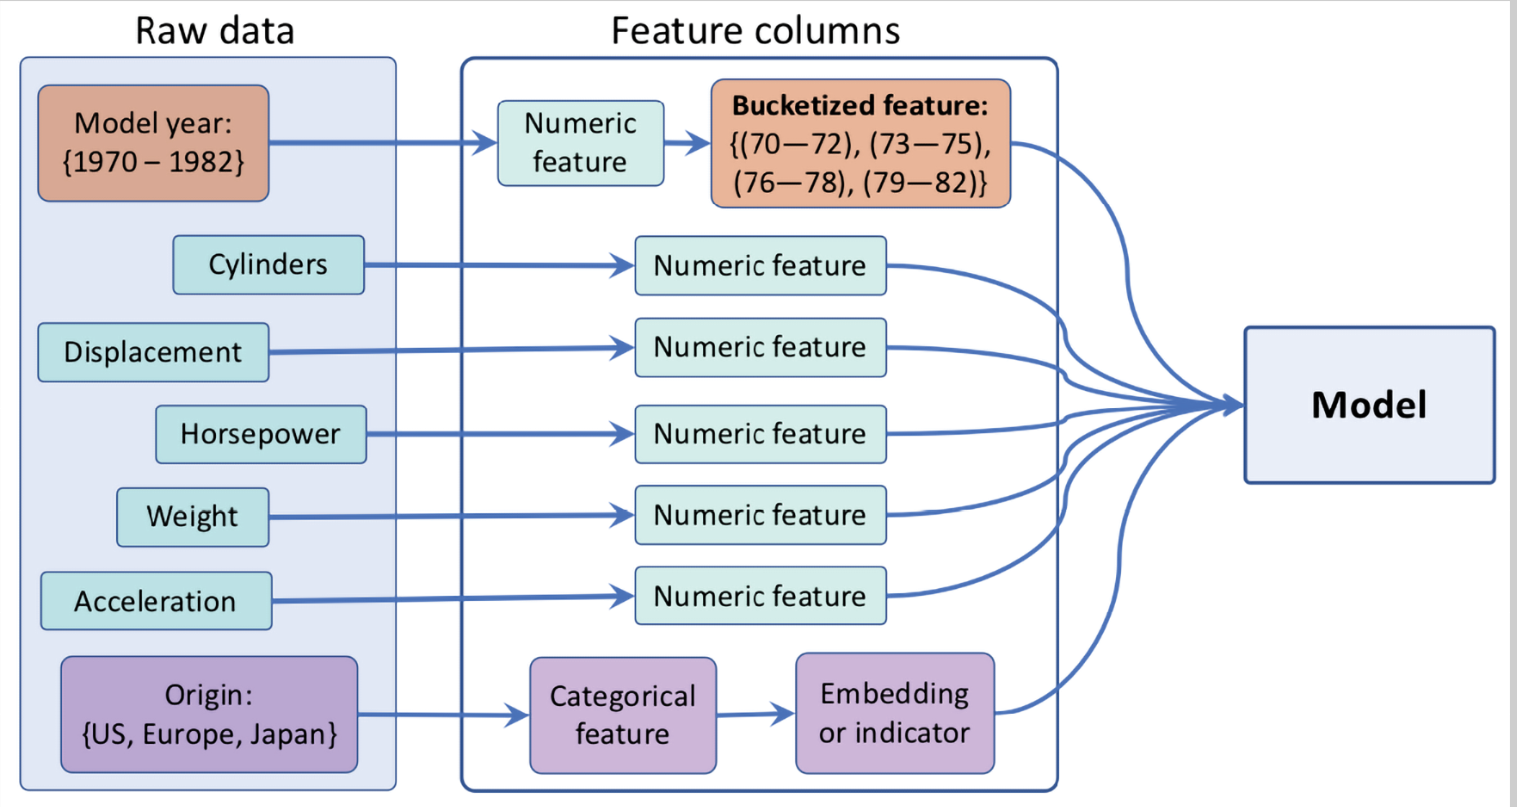


In [1]:
import pandas as pd
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
df = pd.read_csv(url, names = column_names, na_values= "?", comment= '\t', sep= " ", skipinitialspace= True)
df = df.dropna()
df = df.reset_index(drop= True)

import sklearn
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size= 0.2, random_state= 2)

train_stats = df_train.describe().transpose()

numeric_column_names = ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration']
df_train_norm, df_test_norm = df_train.copy(), df_test.copy()
for col_name in numeric_column_names:
    mean = train_stats.loc[col_name, 'mean']
    std  = train_stats.loc[col_name, 'std']
    df_train_norm.loc[:, col_name] = (df_train_norm.loc[:, col_name] - mean)/std
    df_test_norm.loc[:, col_name] =  (df_test_norm.loc[:, col_name] - mean)/std
df_train_norm.tail()

C:\Users\Aron\AppData\Local\Temp\ipykernel_15476\314013079.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.29961227 -0.87262074  1.47184528  0.29961227  0.29961227  0.29961227
 -1.45873724 -0.87262074  0.29961227 -0.87262074 -0.87262074  1.47184528
  0.29961227 -0.87262074 -0.87262074 -0.87262074  1.47184528  1.47184528
  0.29961227  0.29961227 -0.87262074 -0.87262074  1.47184528 -0.87262074
 -0.87262074  0.29961227 -0.87262074 -0.87262074  0.29961227 -0.87262074
 -0.28650423  0.29961227 -0.87262074  0.29961227  0.29961227 -0.87262074
 -0.87262074  1.47184528  0.29961227 -0.87262074  1.47184528 -0.87262074
  0.29961227  1.47184528 -0.87262074 -0.87262074 -0.87262074 -0.87262074
 -0.87262074  0.29961227  0.29961227 -0.87262074 -0.87262074 -0.87262074
  0.29961227 -0.87262074 -0.87262074  1.47184528  1.47184528  1.47184528
 -0.87262074 -0.87262074  1.47184528  0.29961227 -0.87262074 -0.87262074
  1.47184528 

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
299,34.2,-0.872621,-0.848019,-0.895709,-0.906865,-0.827865,79,1
22,25.0,-0.872621,-0.857470,-0.243413,-0.700258,0.716236,70,2
72,13.0,1.471845,1.061039,0.669802,1.333927,-0.540590,72,1
15,22.0,0.299612,0.030904,-0.243413,-0.159540,-0.001950,70,1
168,23.0,-0.872621,-0.517241,-0.686974,-0.444067,1.075329,75,1


now lets group the model year basedon this , and the  preprocess using onehot encoder in python :
 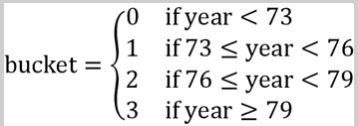

In [3]:
import torch 
boundaries = torch.tensor([73, 76, 79])
v = torch.tensor(df_train_norm['Model Year'].values)
df_train_norm['Model Year Bucketed'] = torch.bucketize(v, boundaries, right=True)
v = torch.tensor(df_test_norm['Model Year'].values)
df_test_norm['Model Year Bucketed'] = torch.bucketize(v, boundaries, right=True)
numeric_column_names.append('Model Year Bucketed')


from torch.nn.functional import one_hot
total_origin = len(set(df_train_norm['Origin']))
origin_encoded = one_hot(torch.from_numpy(df_train_norm['Origin'].values) % total_origin)
x_train_numeric = torch.tensor(df_train_norm[numeric_column_names].values)
x_train = torch.cat([x_train_numeric, origin_encoded], 1).float()
origin_encoded = one_hot(torch.from_numpy(df_test_norm['Origin'].values) % total_origin)
x_test_numeric = torch.tensor( df_test_norm[numeric_column_names].values)
x_test = torch.cat([x_test_numeric, origin_encoded], 1).float()


y_train = torch.tensor(df_train_norm['MPG'].values).float()
y_test = torch.tensor(df_test_norm['MPG'].values).float()

# Training a DNN regression model